<a href="https://colab.research.google.com/github/zrsteff/DSC502-Group-1-Project/blob/main/DSC502_Group_Project_ZRS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Multi-panel Scatter Plot of Predicted vs. Average Percent Viability for Selected Compounds

To further improve readability and focus on each compound of interest, we will create a multi-panel plot. Each panel will display the predicted versus average percent viability for one of the selected compounds, with the 'Other Compounds' data shown in the background for contextual comparison.

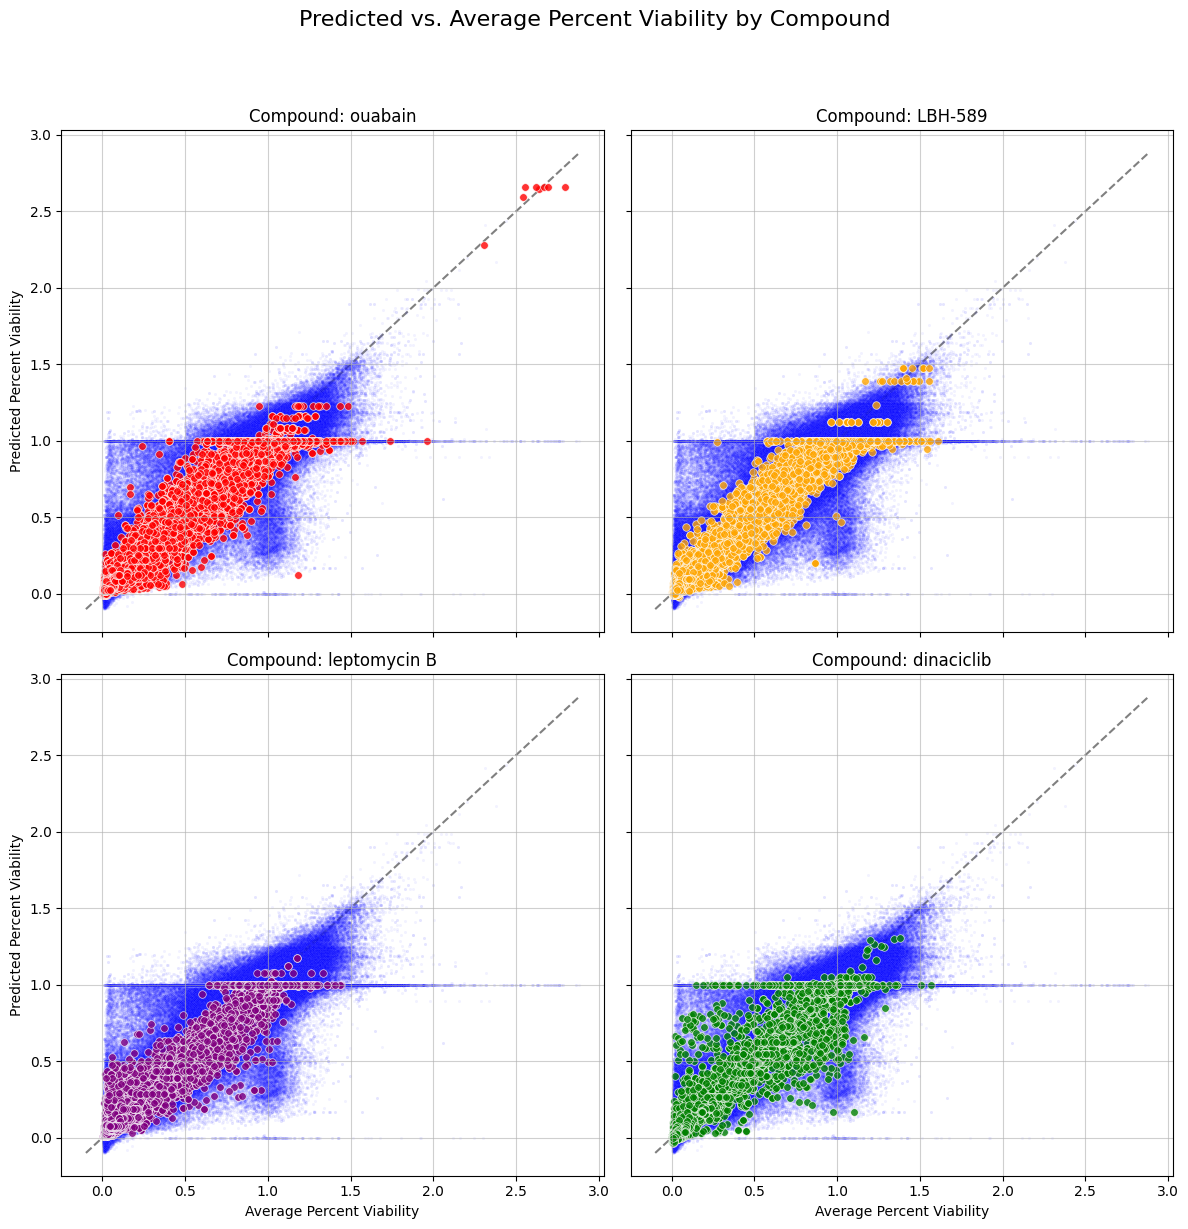

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define custom colors (reusing from previous cell's logic)
colors = {
    'ouabain': 'red',
    'LBH-589': 'orange',
    'leptomycin B': 'purple',
    'dinaciclib': 'green',
    'Other Compounds': 'blue'
}

# Separate data for 'Other Compounds' and selected compounds (reusing from previous cell's logic)
other_compounds_data = plot_data[plot_data['compound_category'] == 'Other Compounds']
selected_compounds_data = plot_data[plot_data['compound_category'] != 'Other Compounds']

# Calculate global min/max for shared axes to ensure consistent scaling
min_val = plot_data[['cpd_avg_pv', 'cpd_pred_pv']].min().min()
max_val = plot_data[['cpd_avg_pv', 'cpd_pred_pv']].max().max()

# Determine grid size for subplots based on the number of selected compounds
num_compounds = len(selected_compound_names)
n_cols = 2  # Arrange in 2 columns
n_rows = (num_compounds + n_cols - 1) // n_cols # Calculate rows needed (ceiling division)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6), sharex=True, sharey=True)
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, compound_name in enumerate(selected_compound_names):
    ax = axes[i]

    # Plot 'Other Compounds' data as background in each panel
    sns.scatterplot(
        data=other_compounds_data,
        x='cpd_avg_pv',
        y='cpd_pred_pv',
        color=colors['Other Compounds'],
        alpha=0.05, # Very low transparency for background context
        s=5,
        ax=ax,
        legend=False
    )

    # Plot the specific selected compound for the current panel
    subset = selected_compounds_data[selected_compounds_data['compound_category'] == compound_name]
    sns.scatterplot(
        data=subset,
        x='cpd_avg_pv',
        y='cpd_pred_pv',
        color=colors[compound_name],
        alpha=0.8,
        s=30, # Slightly smaller than the combined plot for dedicated view
        edgecolor='w',
        linewidth=0.5,
        ax=ax,
        legend=False
    )

    # Plot the perfect agreement line (y=x)
    ax.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', label='Perfect Agreement (y=x)', zorder=0)

    ax.set_title(f'Compound: {compound_name}')
    ax.set_xlabel('Average Percent Viability')
    ax.set_ylabel('Predicted Percent Viability')
    ax.grid(True, alpha=0.6)

# Hide any unused subplots if the number of compounds doesn't perfectly fill the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Predicted vs. Average Percent Viability by Compound', y=1.02, fontsize=16) # Overall title
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

### Additional Visualizations for Context and Insight

#### 1. Individual Compound Dose-Response Across Selected Histology Types

This plot shows the dose-response curves for a specific selected compound (e.g., 'ouabain') across the chosen histology types. It helps visualize how a single compound's efficacy can vary depending on the cell line's histological origin.

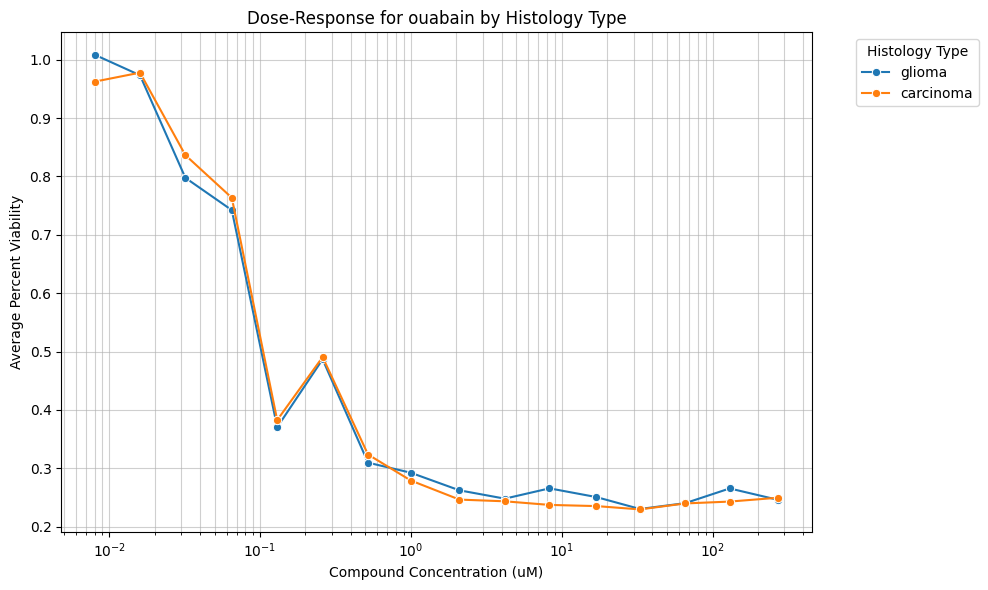

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select one of the compounds for this visualization (e.g., 'ouabain')
single_compound_name = 'ouabain'
single_compound_id = compound_df[compound_df['cpd_name'] == single_compound_name]['master_cpd_id'].iloc[0]

# Filter data for this specific compound and selected histology types
compound_histology_df = final_merged_df[
    (final_merged_df['master_cpd_id'] == single_compound_id) &
    (final_merged_df['ccle_primary_hist'].isin(selected_histology_types))
].copy()
# Clean histology names for display
compound_histology_df['ccle_primary_hist_cleaned'] = compound_histology_df['ccle_primary_hist'].str.replace('_', ' ')

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=compound_histology_df,
    x='cpd_conc_umol',
    y='cpd_avg_pv',
    hue='ccle_primary_hist_cleaned', # Differentiate by cleaned histology name
    marker='o',
    errorbar=None # Avoid error bars for clarity in this aggregated view
)
plt.xscale('log')
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Average Percent Viability')
plt.title(f'Dose-Response for {single_compound_name} by Histology Type')
plt.legend(title='Histology Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

#### 2. Violin Plot of Viability Distribution by Histology for Selected Compounds

This visualization shows the distribution of average percent viability for each of the selected compounds, broken down by primary histology type. Violin plots are useful for seeing the density and spread of data, highlighting how drug response might differ across biological contexts.

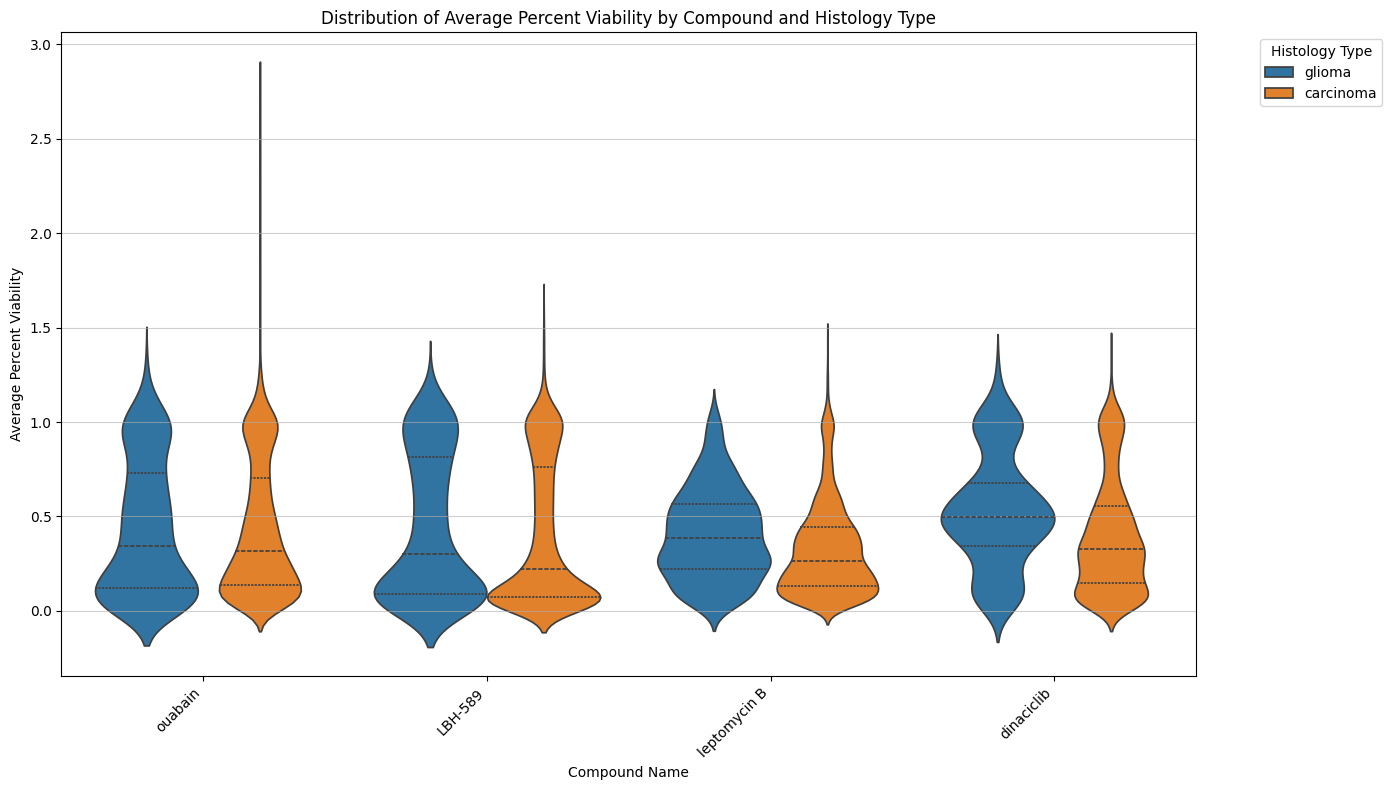

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy to avoid SettingWithCopyWarning if filtered_df is a view
plot_df = filtered_df.copy()
plot_df['ccle_primary_hist_cleaned'] = plot_df['ccle_primary_hist'].str.replace('_', ' ')

plt.figure(figsize=(14, 8))
sns.violinplot(
    data=plot_df,
    x='cpd_name',
    y='cpd_avg_pv',
    hue='ccle_primary_hist_cleaned', # Split by cleaned histology type
    inner='quartile', # Show quartiles inside the violins
    palette='tab10' # A diverse color palette
)
plt.xlabel('Compound Name')
plt.ylabel('Average Percent Viability')
plt.title('Distribution of Average Percent Viability by Compound and Histology Type')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Histology Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

#### 3. Model Residuals vs. Predicted Viability

This plot helps assess the performance of the predictive model. Residuals (the difference between actual and predicted values) are plotted against the predicted values. Ideally, residuals should be randomly scattered around zero, with no clear patterns. Any patterns might indicate biases in the model.

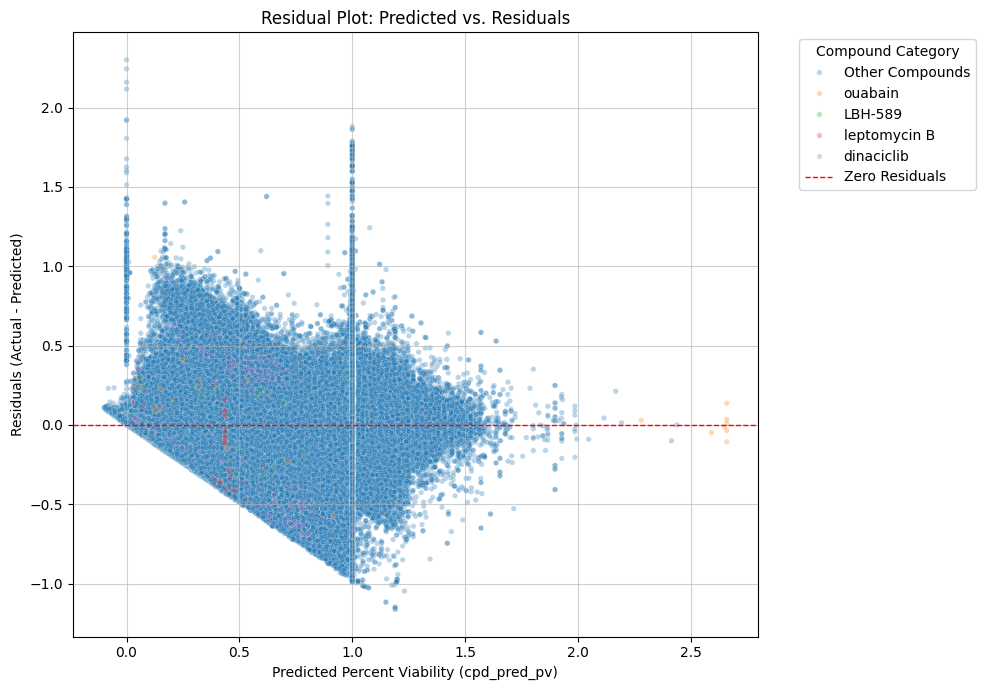

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
plot_data['residual'] = plot_data['cpd_avg_pv'] - plot_data['cpd_pred_pv']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_data,
    x='cpd_pred_pv',
    y='residual',
    hue='compound_category', # Color by compound category
    alpha=0.3,
    s=15,
    legend='brief' # Show legend briefly
)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Residuals')
plt.xlabel('Predicted Percent Viability (cpd_pred_pv)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Predicted vs. Residuals')
plt.legend(title='Compound Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

#### 4. Heatmap of Average Viability by Compound and Histology Type

This heatmap provides a concise overview of the average percent viability for each selected compound across the different primary histology types. It's a quick way to identify compounds that are generally more or less active in certain histological contexts.

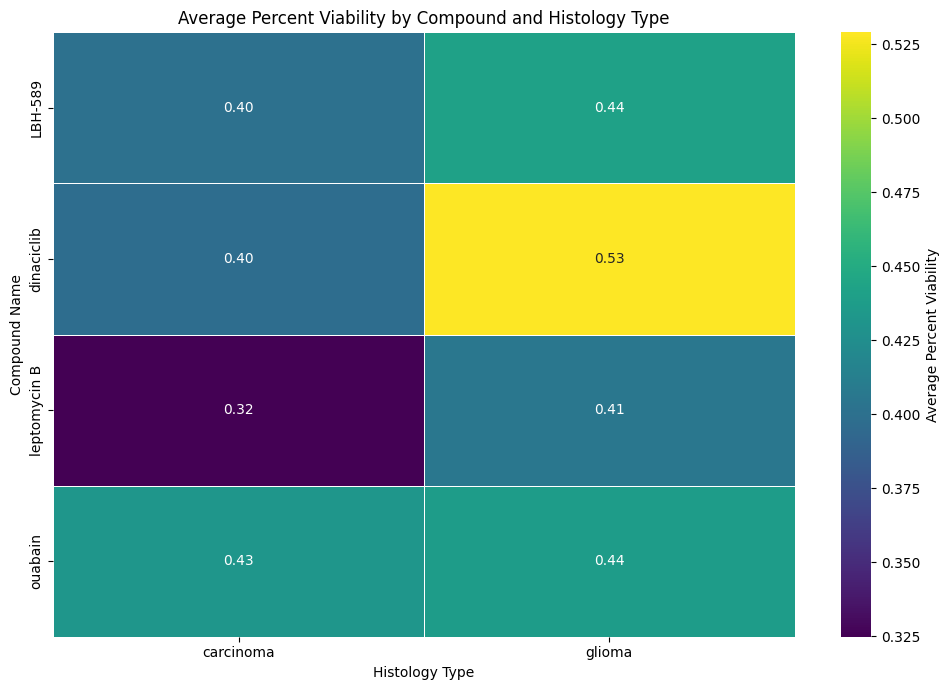

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aggregate the filtered data to get the mean cpd_avg_pv for each compound-histology pair
heatmap_data = filtered_df.groupby(['cpd_name', 'ccle_primary_hist'])['cpd_avg_pv'].mean().unstack()
heatmap_data.columns = heatmap_data.columns.str.replace('_', ' ') # Clean column names

plt.figure(figsize=(10, 7))
sns.heatmap(
    heatmap_data,
    annot=True, # Show the numerical values
    cmap='viridis', # Color map
    fmt=".2f", # Format annotation to two decimal places
    linewidths=.5, # Add lines between cells
    cbar_kws={'label': 'Average Percent Viability'}
)
plt.xlabel('Histology Type')
plt.ylabel('Compound Name')
plt.title('Average Percent Viability by Compound and Histology Type')
plt.tight_layout()
plt.show()

#### 5. Distribution of Model Residuals

This plot (a histogram with a Kernel Density Estimate) shows the overall distribution of the prediction errors (residuals). A good model should have residuals centered around zero and normally distributed. This helps in understanding the magnitude and nature of the model's errors.

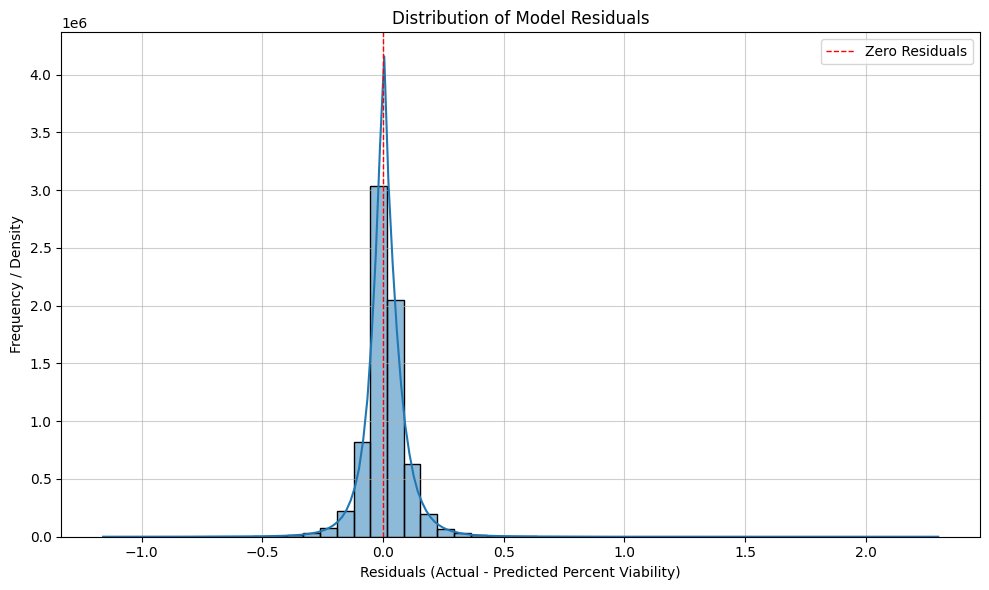

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse the 'residual' column calculated previously in plot_data

plt.figure(figsize=(10, 6))
sns.histplot(plot_data['residual'], bins=50, kde=True)
plt.xlabel('Residuals (Actual - Predicted Percent Viability)')
plt.ylabel('Frequency / Density')
plt.title('Distribution of Model Residuals')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Zero Residuals')
plt.legend()
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

In [22]:
selected_compound_names = ['ouabain', 'LBH-589', 'leptomycin B', 'dinaciclib']
selected_histology_types = ['glioma', 'carcinoma', 'lymphoid neoplasm']

# Get master_cpd_id for the selected compounds
selected_cpd_ids = compound_df[compound_df['cpd_name'].isin(selected_compound_names)]['master_cpd_id'].unique()

# Filter the final_merged_df based on selected compound IDs and histology types
filtered_df = final_merged_df[
    (final_merged_df['master_cpd_id'].isin(selected_cpd_ids)) &
    (final_merged_df['ccle_primary_hist'].isin(selected_histology_types))
].copy()

# Merge with compound_df to get compound names
filtered_df = pd.merge(filtered_df, compound_df[['master_cpd_id', 'cpd_name']], on='master_cpd_id', how='left')

print(f"Number of unique compounds selected: {len(selected_cpd_ids)}")
print(f"Selected compound IDs: {selected_cpd_ids.tolist()}")
print(f"Number of unique histology types selected: {len(selected_histology_types)}")

print("\nFiltered DataFrame Info:")
filtered_df.info()
display(filtered_df.head())

Number of unique compounds selected: 4
Selected compound IDs: [37190, 54210, 660086, 687578]
Number of unique histology types selected: 3

Filtered DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34555 entries, 0 to 34554
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   experiment_id      34555 non-null  int64  
 1   cpd_pv_errorbar    34555 non-null  float64
 2   cpd_pred_pv        34555 non-null  float64
 3   cpd_avg_pv         34555 non-null  float64
 4   cpd_conc_umol      34555 non-null  float64
 5   master_cpd_id      34555 non-null  int64  
 6   master_ccl_id      34555 non-null  int64  
 7   ccl_name           34555 non-null  object 
 8   ccle_primary_site  34555 non-null  object 
 9   ccle_primary_hist  34555 non-null  object 
 10  cpd_name           34555 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 2.9+ MB


,experiment_id,cpd_pv_errorbar,cpd_pred_pv,cpd_avg_pv,cpd_conc_umol,master_cpd_id,master_ccl_id,ccl_name,ccle_primary_site,ccle_primary_hist,cpd_name
0,1,0.0,1.0000,1.2880,0.0081,37190,130,CAS1,central_nervous_system,glioma,ouabain
1,1,0.0,1.0000,1.3140,0.0160,37190,130,CAS1,central_nervous_system,glioma,ouabain
2,1,0.0,1.0000,1.0270,0.0320,37190,130,CAS1,central_nervous_system,glioma,ouabain
3,1,0.0,0.2827,0.2837,0.1300,37190,130,CAS1,central_nervous_system,glioma,ouabain
4,1,0.0,0.2823,0.4262,0.2600,37190,130,CAS1,central_nervous_system,glioma,ouabain


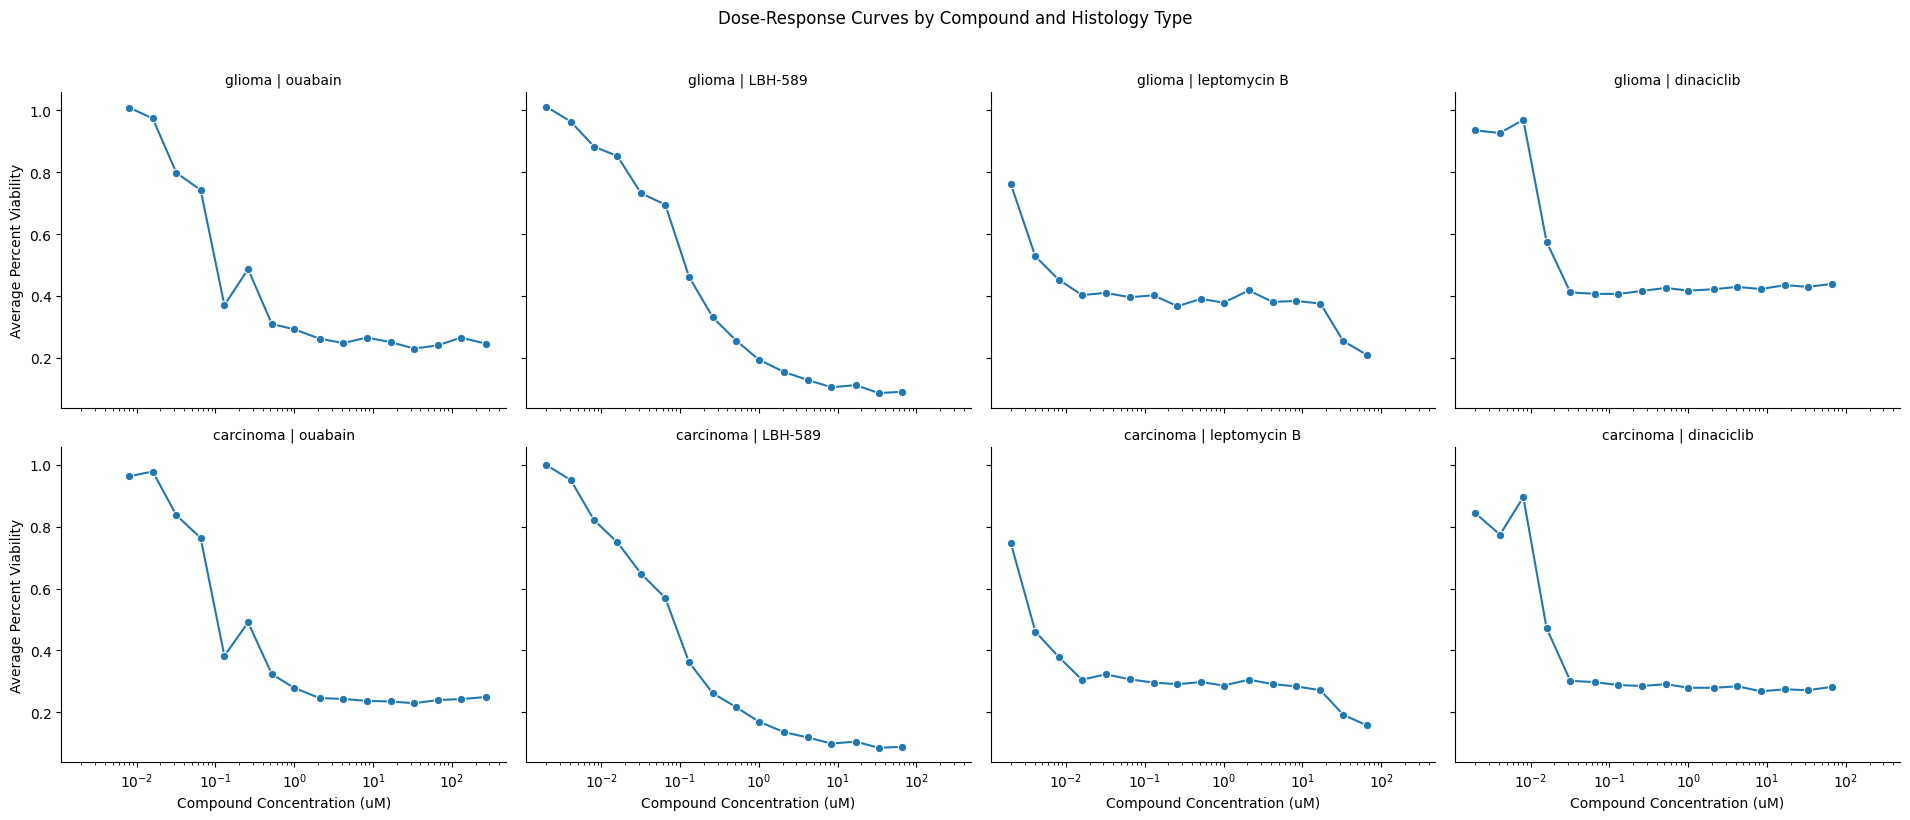

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy to avoid SettingWithCopyWarning if filtered_df is a view
plot_df = filtered_df.copy()
plot_df['ccle_primary_hist_cleaned'] = plot_df['ccle_primary_hist'].str.replace('_', ' ')

g = sns.relplot(
    data=plot_df,
    x='cpd_conc_umol',
    y='cpd_avg_pv',
    col='cpd_name',        # Separate plots by compound name
    row='ccle_primary_hist_cleaned', # Separate plots by histology type using cleaned names
    kind='line',
    marker='o',
    errorbar=None,
    height=4, aspect=1.2,
    facet_kws={'sharex': True, 'sharey': True}
)

g.set(xscale='log')
g.set_axis_labels('Compound Concentration (uM)', 'Average Percent Viability')
g.set_titles(col_template='{col_name}', row_template='{row_name}') # This will now use cleaned row names
g.fig.suptitle('Dose-Response Curves by Compound and Histology Type', y=1.02) # Overall title
g.tight_layout()
plt.show()

In [19]:
compound_meta_path = '/content/drive/My Drive/DSC502ProjectData/v20.meta.per_compound.txt'
compound_df = pd.read_csv(compound_meta_path, sep='\t')

print("Compound Metadata Info:")
compound_df.info()
display(compound_df.head())

Compound Metadata Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   master_cpd_id                   545 non-null    int64  
 1   cpd_name                        545 non-null    object 
 2   broad_cpd_id                    545 non-null    object 
 3   top_test_conc_umol              545 non-null    float64
 4   cpd_status                      545 non-null    object 
 5   inclusion_rationale             545 non-null    object 
 6   gene_symbol_of_protein_target   415 non-null    object 
 7   target_or_activity_of_compound  545 non-null    object 
 8   source_name                     495 non-null    object 
 9   source_catalog_id               359 non-null    object 
 10  cpd_smiles                      545 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 47.0+ KB


,master_cpd_id,cpd_name,broad_cpd_id,top_test_conc_umol,cpd_status,inclusion_rationale,gene_symbol_of_protein_target,target_or_activity_of_compound,source_name,source_catalog_id,cpd_smiles
0,1788,CIL55,BRD-K46556387,10.0,probe,pilot-set,NaN,screening hit,Columbia University,NaN,CN(C)CCNC(=O)c1cc2CSc3cc(Cl)ccc3-c2s1
1,3588,BRD4132,BRD-K86574132,160.0,probe,chromatin;pilot-set,NaN,screening hit,ChemDiv Inc.,4998-1380,CC(C)N1C(=O)S\C(=C\c2ccc(Sc3nc4ccccc4[nH]3)o2)...
2,12877,BRD6340,BRD-K35716340,33.0,probe,chromatin;pilot-set,NaN,screening hit,ChemDiv Inc.,1988-0090,C(Cn1c2ccccc2c2ccccc12)c1nc2ccccc2[nH]1
3,17712,ML006,BRD-K89692698,530.0,probe,pilot-set,S1PR3,agonist of sphingosine 1-phosphate receptor 3,Enamine Ltd.,Z1037336336,C1CN(CCO1)c1nnc(-c2ccccc2)c(n1)-c1ccccc1
4,18311,Bax channel blocker,BRD-A18763547,33.0,probe,pilot-set,BAX,inhibitor of BAX-mediated mitochondrial cytoch...,Maybridge,RJC01737,OC(CN1CCNCC1)Cn1c2ccc(Br)cc2c2cc(Br)ccc12


In [ ]:
!ls '/content/drive/My Drive/DSC502ProjectData'

CTRPv2.0._COLUMNS.xlsx	      v20.data.per_cpd_pre_qc.txt
CTRPv2.0._INFORMER_SET.xlsx   v20.data.per_cpd_well.txt
CTRPv2.0._README.docx	      v20.meta.media_comp.txt
MANIFEST.txt		      v20.meta.per_assay_plate.txt
v20._COLUMNS.txt	      v20.meta.per_cell_line.txt
v20.data.curves_post_qc.txt   v20.meta.per_compound.txt
v20.data.per_cpd_avg.txt      v20.meta.per_experiment.txt
v20.data.per_cpd_post_qc.txt  v20._README.txt


In [ ]:
file_path = '/content/drive/My Drive/DSC502ProjectData/v20.data.per_cpd_post_qc.txt'


In [ ]:
import pandas as pd
df = pd.read_csv(file_path, sep='\t')
display(df.head())

,experiment_id,cpd_pv_errorbar,cpd_pred_pv,cpd_avg_pv,cpd_conc_umol,master_cpd_id
0,1,0.000058,1.0,0.9303,0.00030,1788
1,1,0.000058,1.0,0.8337,0.00061,1788
2,1,0.000058,1.0,1.0460,0.00120,1788
3,1,0.000058,1.0,1.0910,0.00240,1788
4,1,0.000058,1.0,1.0190,0.00490,1788


## Explore Data Types and Summary Statistics

In [ ]:
print("Data types of all columns:")
df.info()

print("\nDescriptive statistics for all columns:")
display(df.describe())

print("\nDescriptive statistics for 'cpd_avg_pv' and 'cpd_conc_umol':")
display(df[['cpd_avg_pv', 'cpd_conc_umol']].describe())

Data types of all columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6171005 entries, 0 to 6171004
Data columns (total 6 columns):
 #   Column           Dtype  
---  ------           -----  
 0   experiment_id    int64  
 1   cpd_pv_errorbar  float64
 2   cpd_pred_pv      float64
 3   cpd_avg_pv       float64
 4   cpd_conc_umol    float64
 5   master_cpd_id    int64  
dtypes: float64(4), int64(2)
memory usage: 282.5 MB

Descriptive statistics for all columns:


,experiment_id,cpd_pv_errorbar,cpd_pred_pv,cpd_avg_pv,cpd_conc_umol,master_cpd_id
count,6.171005e+06,6.171005e+06,6.171005e+06,6.171005e+06,6.171005e+06,6.171005e+06
mean,4.577973e+02,8.192664e+24,8.462978e-01,8.555860e-01,9.837174e+00,4.557644e+05
std,2.621522e+02,2.815797e+27,2.812886e-01,3.013601e-01,3.253056e+01,2.308714e+05
min,1.000000e+00,0.000000e+00,-9.968000e-02,1.922000e-03,4.000000e-06,1.788000e+03
25%,2.280000e+02,1.488000e-06,8.271000e-01,8.016000e-01,1.600000e-02,3.747470e+05
50%,4.600000e+02,2.684000e-02,9.948000e-01,9.660000e-01,2.600000e-01,5.968680e+05
75%,6.840000e+02,8.242000e-02,1.000000e+00,1.033000e+00,4.200000e+00,6.601760e+05
max,9.070000e+02,1.672000e+30,2.659000e+00,2.881000e+00,6.000000e+02,7.101540e+05



Descriptive statistics for 'cpd_avg_pv' and 'cpd_conc_umol':


,cpd_avg_pv,cpd_conc_umol
count,6.171005e+06,6.171005e+06
mean,8.555860e-01,9.837174e+00
std,3.013601e-01,3.253056e+01
min,1.922000e-03,4.000000e-06
25%,8.016000e-01,1.600000e-02
50%,9.660000e-01,2.600000e-01
75%,1.033000e+00,4.200000e+00
max,2.881000e+00,6.000000e+02


## Visualize Dose-Response Curves

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_cpds = df['master_cpd_id'].unique()

num_compounds_to_plot = 5
sampled_cpd_ids = unique_cpds[:num_compounds_to_plot]

sampled_df = df[df['master_cpd_id'].isin(sampled_cpd_ids)]

print(f"Original DataFrame size: {len(df)} rows")
print(f"Sampled DataFrame size: {len(sampled_df)} rows for {num_compounds_to_plot} compounds.")

Original DataFrame size: 6171005 rows
Sampled DataFrame size: 56080 rows for 5 compounds.


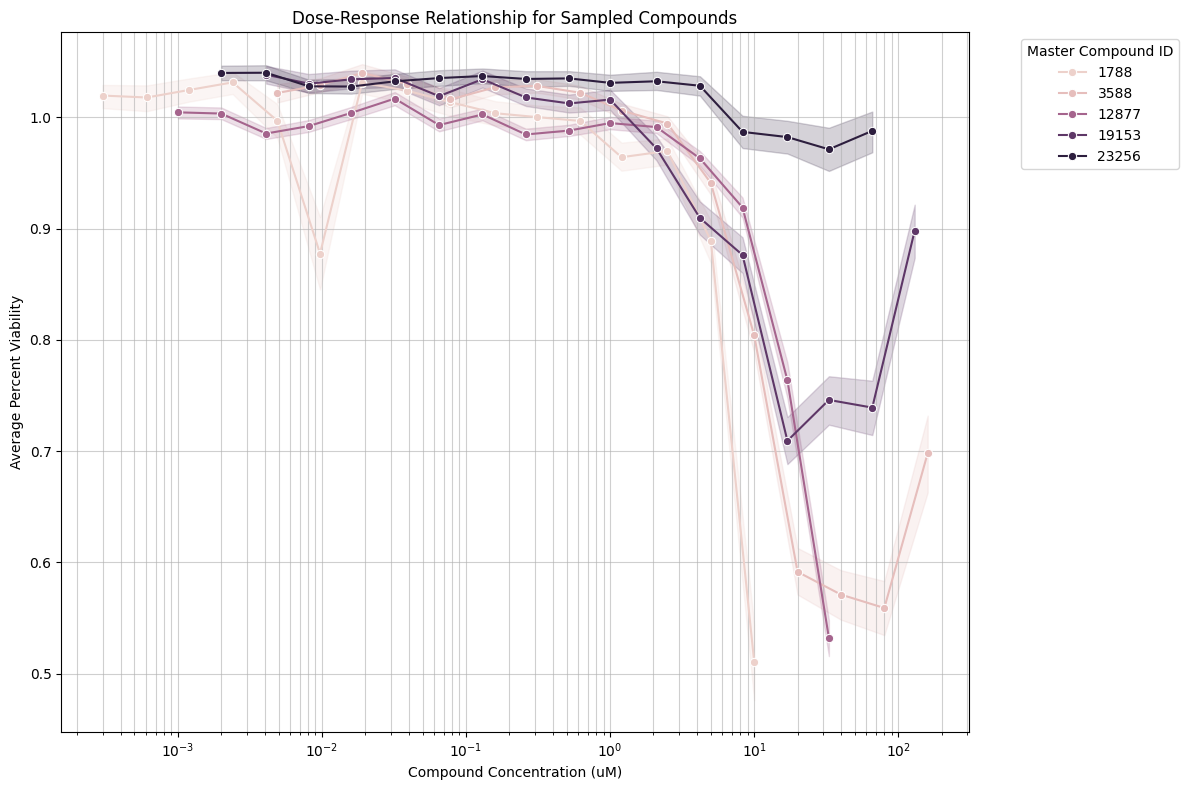

In [ ]:
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=sampled_df,
    x='cpd_conc_umol',
    y='cpd_avg_pv',
    hue='master_cpd_id',
    marker='o'
)
plt.xscale('log')
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Average Percent Viability')
plt.title('Dose-Response Relationship for Sampled Compounds')
plt.legend(title='Master Compound ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()


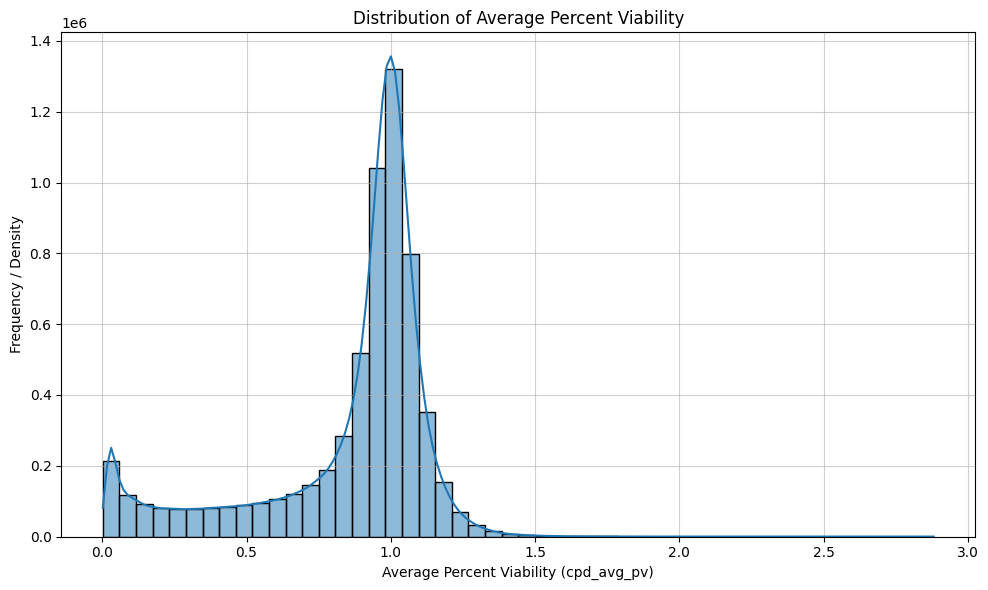

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cpd_avg_pv'], bins=50, kde=True)
plt.xlabel('Average Percent Viability (cpd_avg_pv)')
plt.ylabel('Frequency / Density')
plt.title('Distribution of Average Percent Viability')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

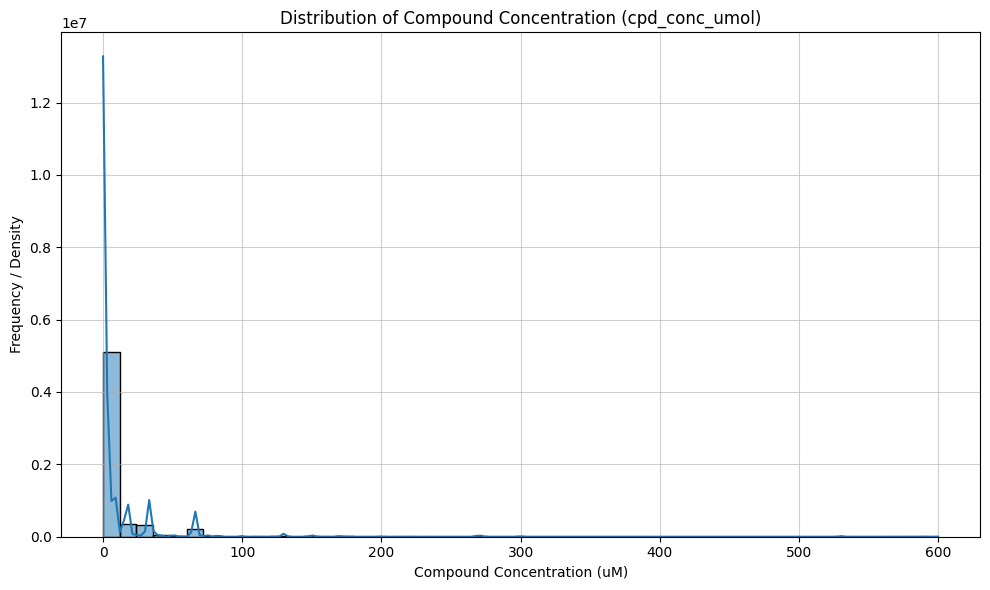

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cpd_conc_umol'], bins=50, kde=True)
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Frequency / Density')
plt.title('Distribution of Compound Concentration (cpd_conc_umol)')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

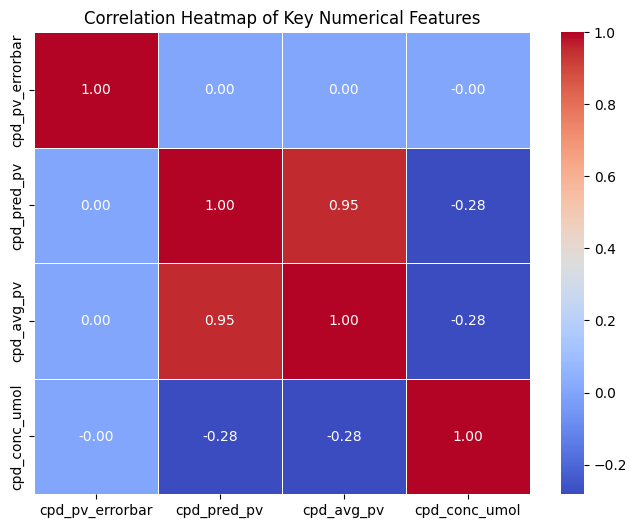

In [ ]:
selected_columns = ['cpd_pv_errorbar', 'cpd_pred_pv', 'cpd_avg_pv', 'cpd_conc_umol']
correlation_matrix = df[selected_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.show()

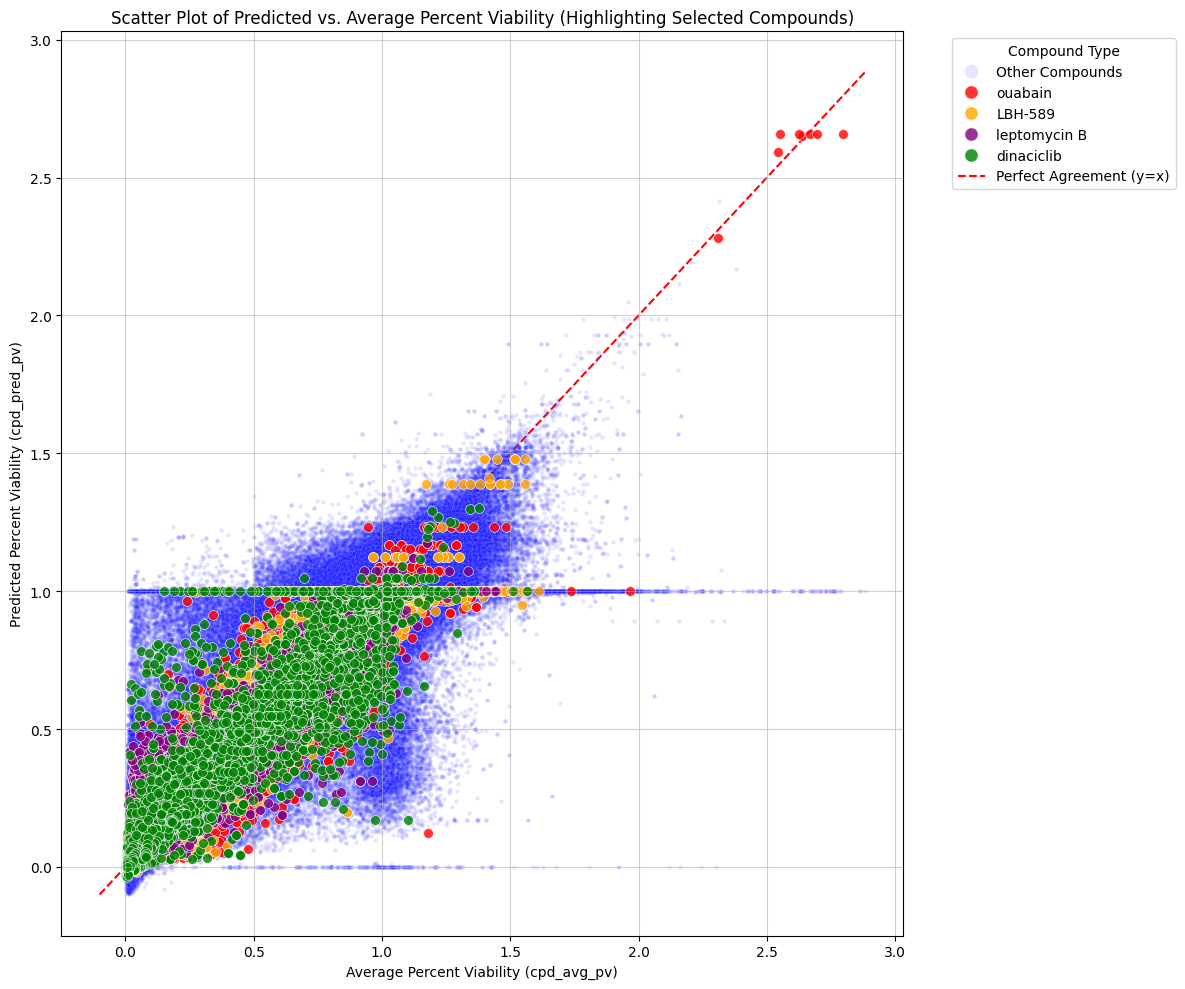

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Make a copy of relevant columns from final_merged_df to avoid SettingWithCopyWarning
plot_data = final_merged_df[['cpd_avg_pv', 'cpd_pred_pv', 'master_cpd_id']].copy()

# Create a 'compound_category' for hue: actual name for selected, 'Other Compounds' for the rest
compound_name_map = compound_df[compound_df['master_cpd_id'].isin(selected_cpd_ids)].set_index('master_cpd_id')['cpd_name'].to_dict()
plot_data['compound_category'] = plot_data['master_cpd_id'].map(compound_name_map).fillna('Other Compounds')

plt.figure(figsize=(12, 10))

# Define custom colors
colors = {
    'ouabain': 'red',
    'LBH-589': 'orange',
    'leptomycin B': 'purple',
    'dinaciclib': 'green',
    'Other Compounds': 'blue'
}

# Separate data for 'Other Compounds' and selected compounds
other_compounds_data = plot_data[plot_data['compound_category'] == 'Other Compounds']
selected_compounds_data = plot_data[plot_data['compound_category'] != 'Other Compounds']

# Plot 'Other Compounds' first with low alpha and blue color
sns.scatterplot(
    data=other_compounds_data,
    x='cpd_avg_pv',
    y='cpd_pred_pv',
    color=colors['Other Compounds'], # Explicitly set color to blue
    alpha=0.1, # Low transparency
    s=10, # Small size
    legend=False # Disable legend for this call
)

# Plot selected compounds with higher alpha and specific colors
# Iterate through each selected compound to plot them individually with specific attributes
for compound_name in selected_compound_names:
    subset = selected_compounds_data[selected_compounds_data['compound_category'] == compound_name]
    sns.scatterplot(
        data=subset,
        x='cpd_avg_pv',
        y='cpd_pred_pv',
        color=colors[compound_name], # Use custom color
        alpha=0.8, # Less transparent
        s=50, # Larger size for 'bold' effect
        edgecolor='w', # White edge for clarity
        linewidth=0.5,
        legend=False # Disable legend for this call
    )

# Plot the ideal line (y=x) based on the data's min and max viability values
min_val = plot_data[['cpd_avg_pv', 'cpd_pred_pv']].min().min()
max_val = plot_data[['cpd_avg_pv', 'cpd_pred_pv']].max().max()
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Agreement (y=x)', zorder=0)

plt.xlabel('Average Percent Viability (cpd_avg_pv)')
plt.ylabel('Predicted Percent Viability (cpd_pred_pv)')
plt.title('Scatter Plot of Predicted vs. Average Percent Viability (Highlighting Selected Compounds)')

# Create custom legend handles and labels
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Other Compounds',
           markerfacecolor=colors['Other Compounds'], markersize=10, alpha=0.1)
]

for compound_name in selected_compound_names:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', label=compound_name,
               markerfacecolor=colors[compound_name], markersize=10, alpha=0.8)
    )

legend_elements.append(
    Line2D([0], [0], color='red', linestyle='--', label='Perfect Agreement (y=x)')
)

plt.legend(handles=legend_elements, title='Compound Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

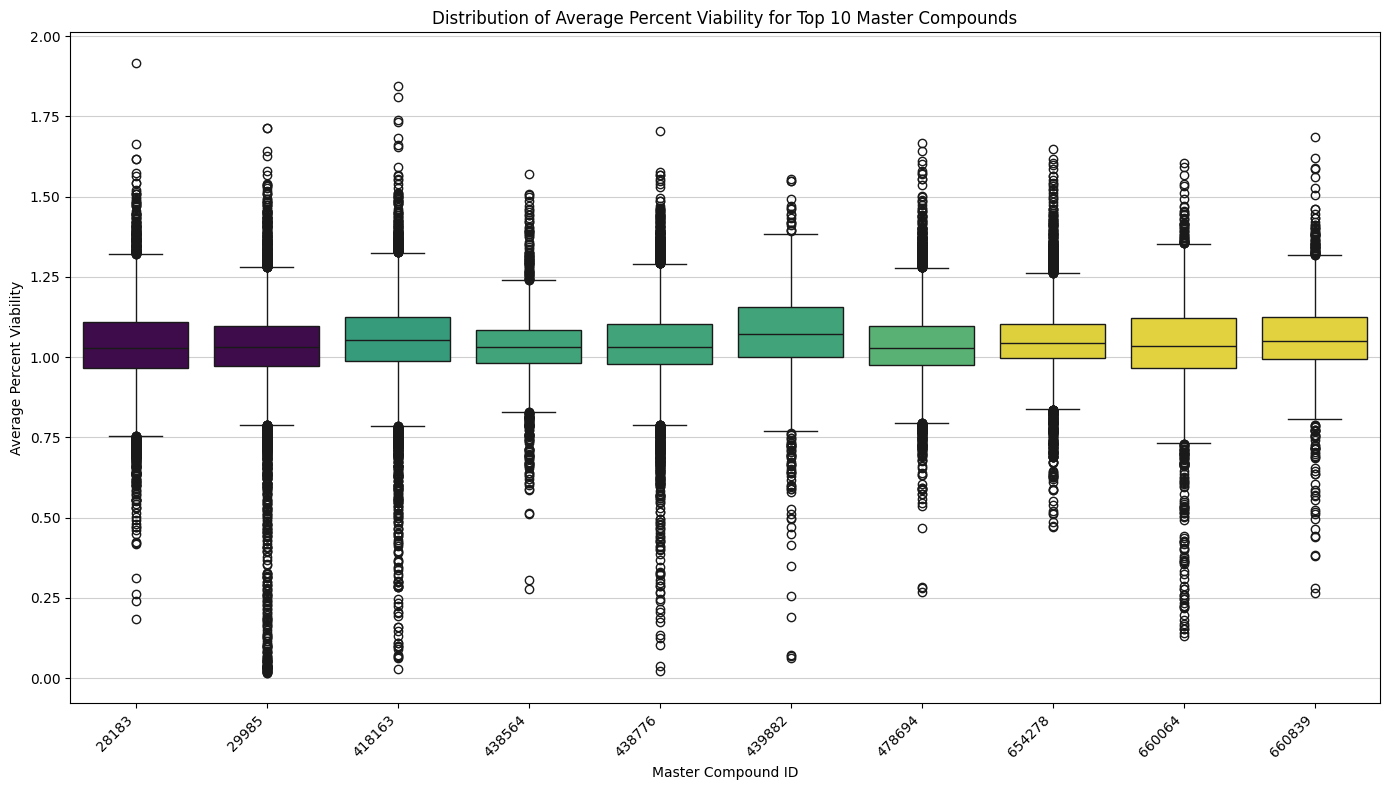

In [ ]:
top_10_cpds = df.groupby('master_cpd_id')['cpd_avg_pv'].mean().nlargest(10)
top_10_cpd_ids = top_10_cpds.index
df_top_10_cpds = df[df['master_cpd_id'].isin(top_10_cpd_ids)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_top_10_cpds, x='master_cpd_id', y='cpd_avg_pv', hue='master_cpd_id', palette='viridis', legend=False)
plt.xlabel('Master Compound ID')
plt.ylabel('Average Percent Viability')
plt.title('Distribution of Average Percent Viability for Top 10 Master Compounds')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

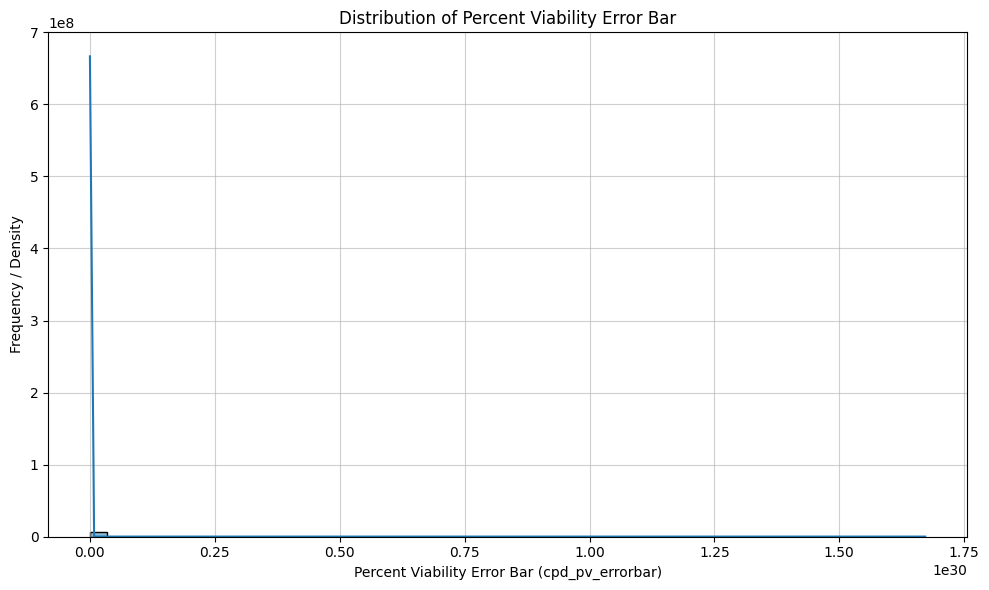

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cpd_pv_errorbar'], bins=50, kde=True)
plt.xlabel('Percent Viability Error Bar (cpd_pv_errorbar)')
plt.ylabel('Frequency / Density')
plt.title('Distribution of Percent Viability Error Bar')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

Plotting dose-response curves for experiment ID: 102


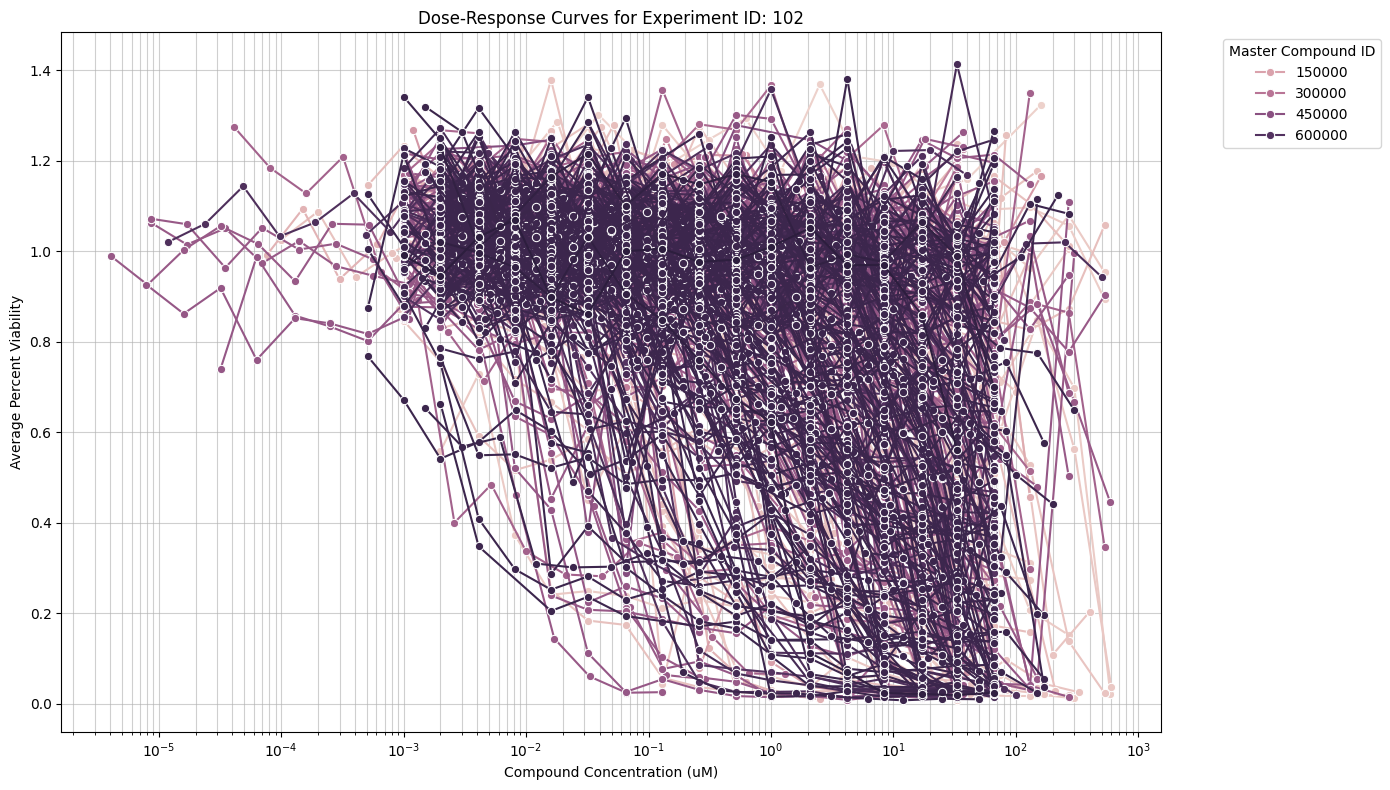

In [ ]:
selected_experiment_id = df['experiment_id'].sample(1).iloc[0]
print(f"Plotting dose-response curves for experiment ID: {selected_experiment_id}")

df_experiment = df[df['experiment_id'] == selected_experiment_id]

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_experiment,
    x='cpd_conc_umol',
    y='cpd_avg_pv',
    hue='master_cpd_id',
    marker='o',
    errorbar=None #avoid plotting error bars by default
)
plt.xscale('log')
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Average Percent Viability')
plt.title(f'Dose-Response Curves for Experiment ID: {selected_experiment_id}')
plt.legend(title='Master Compound ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

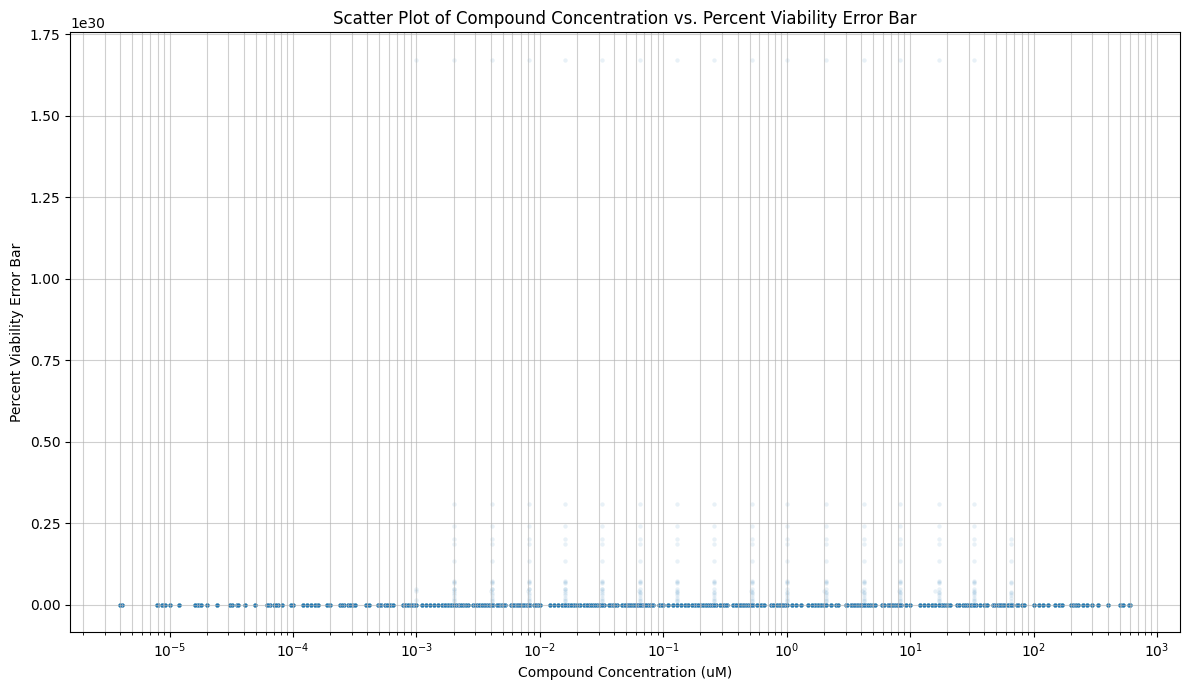

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='cpd_conc_umol', y='cpd_pv_errorbar', alpha=0.1, s=10)
plt.xscale('log')
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Percent Viability Error Bar')
plt.title('Scatter Plot of Compound Concentration vs. Percent Viability Error Bar')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

In [16]:
cell_line_meta_path = '/content/drive/My Drive/DSC502ProjectData/v20.meta.per_cell_line.txt'
experiment_meta_path = '/content/drive/My Drive/DSC502ProjectData/v20.meta.per_experiment.txt'

cell_line_df = pd.read_csv(cell_line_meta_path, sep='\t')
experiment_df = pd.read_csv(experiment_meta_path, sep='\t')

print("Cell Line Metadata Info:")
cell_line_df.info()
display(cell_line_df.head())

print("\nExperiment Metadata Info:")
experiment_df.info()
display(experiment_df.head())

Cell Line Metadata Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   master_ccl_id        1107 non-null   int64 
 1   ccl_name             1107 non-null   object
 2   ccl_availability     1107 non-null   object
 3   ccle_primary_site    1045 non-null   object
 4   ccle_primary_hist    1032 non-null   object
 5   ccle_hist_subtype_1  779 non-null    object
dtypes: int64(1), object(5)
memory usage: 52.0+ KB


,master_ccl_id,ccl_name,ccl_availability,ccle_primary_site,ccle_primary_hist,ccle_hist_subtype_1
0,1,697,ccle;public,haematopoietic_and_lymphoid_tissue,lymphoid_neoplasm,acute_lymphoblastic_B_cell_leukaemia
1,3,5637,ccle;public,urinary_tract,carcinoma,NaN
2,4,2313287,ccle;public,stomach,carcinoma,adenocarcinoma
3,5,1321N1,ccle,central_nervous_system,glioma,astrocytoma
4,6,143B,ccle,bone,osteosarcoma,NaN



Experiment Metadata Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experiment_id    1061 non-null   int64  
 1   run_id           1061 non-null   object 
 2   experiment_date  1061 non-null   int64  
 3   culture_media    1061 non-null   object 
 4   baseline_signal  1061 non-null   float64
 5   cells_per_well   1061 non-null   int64  
 6   growth_mode      1061 non-null   object 
 7   snp_fp_status    1061 non-null   object 
 8   master_ccl_id    1061 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 74.7+ KB


,experiment_id,run_id,experiment_date,culture_media,baseline_signal,cells_per_well,growth_mode,snp_fp_status,master_ccl_id
0,1,7024-01-A01-02-01,20120501,DMEM001,0.2225,500,adherent,SNP-matched-reference,130
1,2,7024-01-A01-02-01,20120501,DMEM001,0.2225,500,adherent,SNP-matched-reference,569
2,3,7024-01-A01-02-01,20120501,RPMI001,0.1195,500,adherent,SNP-matched-reference,682
3,4,7024-01-A01-02-02,20120504,DMEM001,0.2225,500,adherent,SNP-unconfirmed,9
4,5,7024-01-A01-02-02,20120504,DMEM001,0.2225,500,adherent,SNP-matched-reference,61


In [18]:
# Merge df with experiment_df on 'experiment_id' to get 'master_ccl_id'
merged_df = pd.merge(df, experiment_df[['experiment_id', 'master_ccl_id']], on='experiment_id', how='left')

# Merge the result with cell_line_df on 'master_ccl_id' to get histology information
final_merged_df = pd.merge(merged_df, cell_line_df[['master_ccl_id', 'ccl_name', 'ccle_primary_site', 'ccle_primary_hist']], on='master_ccl_id', how='left')

print("Final Merged DataFrame Info:")
final_merged_df.info()
display(final_merged_df.head())

Final Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7227951 entries, 0 to 7227950
Data columns (total 10 columns):
 #   Column             Dtype  
---  ------             -----  
 0   experiment_id      int64  
 1   cpd_pv_errorbar    float64
 2   cpd_pred_pv        float64
 3   cpd_avg_pv         float64
 4   cpd_conc_umol      float64
 5   master_cpd_id      int64  
 6   master_ccl_id      int64  
 7   ccl_name           object 
 8   ccle_primary_site  object 
 9   ccle_primary_hist  object 
dtypes: float64(4), int64(3), object(3)
memory usage: 551.4+ MB


,experiment_id,cpd_pv_errorbar,cpd_pred_pv,cpd_avg_pv,cpd_conc_umol,master_cpd_id,master_ccl_id,ccl_name,ccle_primary_site,ccle_primary_hist
0,1,0.000058,1.0,0.9303,0.00030,1788,130,CAS1,central_nervous_system,glioma
1,1,0.000058,1.0,0.8337,0.00061,1788,130,CAS1,central_nervous_system,glioma
2,1,0.000058,1.0,1.0460,0.00120,1788,130,CAS1,central_nervous_system,glioma
3,1,0.000058,1.0,1.0910,0.00240,1788,130,CAS1,central_nervous_system,glioma
4,1,0.000058,1.0,1.0190,0.00490,1788,130,CAS1,central_nervous_system,glioma


Now that the data is merged, we can visualize dose-response curves for specific compounds by histology group.

### Dose-Response Curves for LBH-589 Across All Histology Groups

This plot displays the dose-response behavior of 'LBH-589' across all primary histology types present in the dataset, with each histology group color-coded for easy comparison.

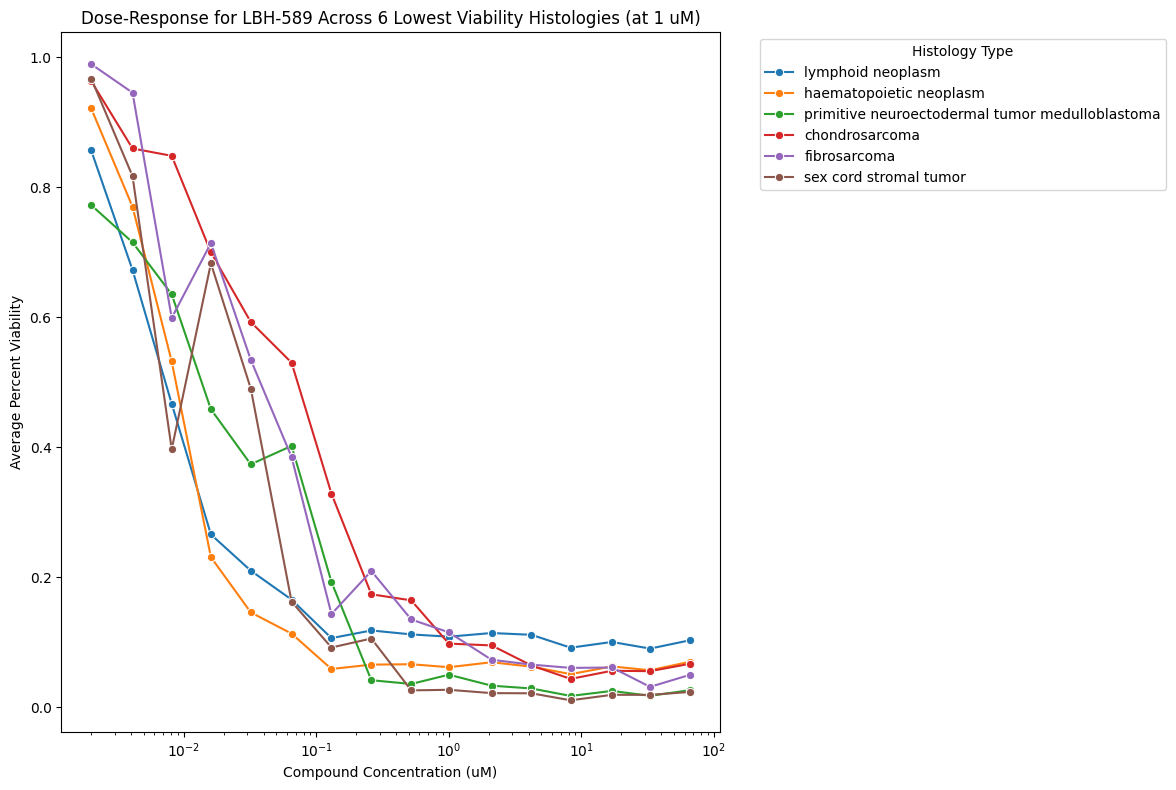

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for isclose

# Select LBH-589 for this visualization
single_compound_name = 'LBH-589'
single_compound_id = compound_df[compound_df['cpd_name'] == single_compound_name]['master_cpd_id'].iloc[0]

# Filter data for this specific compound, including ALL histology types
compound_LBH589_all_histology_df = final_merged_df[
    (final_merged_df['master_cpd_id'] == single_compound_id)
].copy()
# Clean histology names for display
compound_LBH589_all_histology_df['ccle_primary_hist_cleaned'] = compound_LBH589_all_histology_df['ccle_primary_hist'].str.replace('_', ' ')

# Define the target concentration (10^0 uM = 1 uM)
target_concentration = 1.0

# Filter data points at or very near the target concentration
df_at_target_conc = compound_LBH589_all_histology_df[
    np.isclose(compound_LBH589_all_histology_df['cpd_conc_umol'], target_concentration)
].copy()

# Calculate average percent viability for each histology at the target concentration
avg_pv_at_target_conc_by_histology = df_at_target_conc.groupby('ccle_primary_hist_cleaned')['cpd_avg_pv'].mean().sort_values()

# Select the top 6 histologies with the lowest average percent viability at this concentration
lowest_pv_histologies = avg_pv_at_target_conc_by_histology.head(6).index.tolist()

# Filter the original DataFrame (all concentrations) to include only these lowest viability histologies
filtered_LBH589_histologies_df = compound_LBH589_all_histology_df[
    compound_LBH589_all_histology_df['ccle_primary_hist_cleaned'].isin(lowest_pv_histologies)
]

plt.figure(figsize=(12, 8))
sns.lineplot(
    data=filtered_LBH589_histologies_df,
    x='cpd_conc_umol',
    y='cpd_avg_pv',
    hue='ccle_primary_hist_cleaned', # Differentiate by the filtered cleaned histology types
    marker='o',
    errorbar=None # Avoid error bars for clarity
)
plt.xscale('log')
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Average Percent Viability')
plt.title(f'Dose-Response for {single_compound_name} Across 6 Lowest Viability Histologies (at 1 uM)')
plt.legend(title='Histology Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.tight_layout()
plt.show()